In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Problem 2: predicting New York City energy production

**Part 1:** Follow the [instruction I](https://github.com/um-perez-alvaro/Data-Science-Practice/blob/master/Jupyter%20Notebooks/Random%20Forests/homework/Instructions%201.docx?raw=true) and [instruction II](https://github.com/um-perez-alvaro/Data-Science-Practice/blob/master/Jupyter%20Notebooks/Random%20Forests/homework/Instructions%202.docx?raw=true) documents to download the weather and energy production datasets. 
Then, run the cell below.

In [2]:
# load weather data
path = 'weather_NYC.csv' 
data = pd.read_csv(path,index_col='DATE',parse_dates=True)

# load energy consumption datasets
df_list = []
file_paths = ['load_NYC_2018.csv', 'load_NYC_2019.csv']
for file in file_paths:
    df = pd.read_csv(file, 
                     usecols = ['RTD End Time Stamp','RTD Actual Load'], 
                     index_col='RTD End Time Stamp', 
                     parse_dates=True)
    df_list.append(df) 
data['LOAD'] = pd.concat(df_list).resample('d').mean() # average energy production
data.head()

,STATION,NAME,AWND,PGTM,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,...,WSF5,WT01,WT02,WT03,WT04,WT05,WT06,WT08,WT09,LOAD
DATE,,,,,,,,,,,,,,,,,,,,,
2018-01-01,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",17.67,NaN,0.00,0.0,0.0,12,18,7,...,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1719.182034
2018-01-02,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",15.66,NaN,0.00,0.0,0.0,18,26,13,...,29.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1764.714815
2018-01-03,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",8.28,NaN,0.00,0.0,0.0,21,28,12,...,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1699.275172
2018-01-04,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",28.19,NaN,0.49,8.0,1.2,25,29,19,...,55.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1722.843750
2018-01-05,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",25.05,NaN,0.00,0.0,7.9,15,19,9,...,46.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1773.566997


**Column descriptions:**

| column | description |
| :-- | --: |
| AWND | Average wind speed |
| PGTM | Peak gust time |
| PRCP | Precipitation |
| SNOW | Snowfall |
| SNWD | Snow depth |
| TAVG | Average Temperature |
| TMAX | Maximum temperature |
| TMIN | Minimum temperature |
| WDF2 | Direction of fastest 2-minute wind |
| WDF5 | Direction of fastest 5-second wind |
| WSF2 | Fastest 2-minute wind speed |
| WSF5 | Fastest 5-second wind speed |
| WT01 | Fog, ice fog, or freezing fog (may include heavy fog) |
| WT02 | Heavy fog or heaving freezing fog (not always distinguished from fog) |
| WT03 | Thunder |
| WT04 | Ice pellets, sleet, snow pellets, or small hail |
| WT05 | Hail (may include small hail) |
| WT06 | Glaze or rime |
| WT08 | Smoke or haze |
| WT09 | Blowing or drifting snow | 
| LOAD (**target vector**) | average electricity produced (in Watts) in the CAPITAL zone (see the picture below) |

![zones](nyc_zones.png)

Text(0.5, 0, 'date')

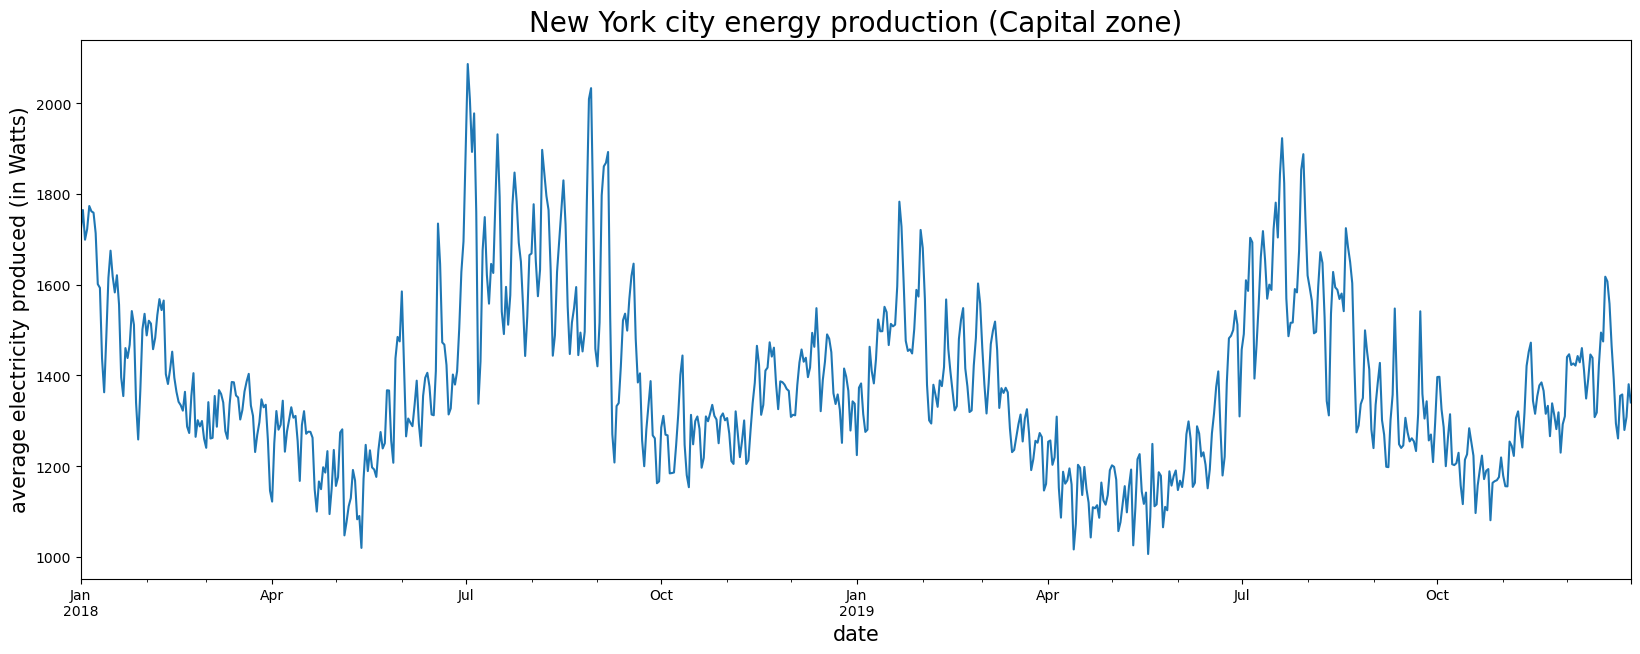

In [3]:
fig, ax = plt.subplots(figsize=(20,7))
data.LOAD.plot(ax=ax)
ax.set_title('New York city energy production (Capital zone)',fontsize=20)
ax.set_ylabel('average electricity produced (in Watts)', fontsize=15)
ax.set_xlabel('date', fontsize=15)

**Part 2:** add new columns  indicating the day of the week, the month, and whether a given date is a holiday.

In [4]:
data['day_of_week']=pd.to_datetime(data.index).dayofweek
data['month']=pd.to_datetime(data.index).month

**Part 3:** define the matrix X and the target vector y (column `LOAD`)

In [5]:
data.columns[-3]

'LOAD'

In [6]:
# feature matrix/target vector
X = data.drop(['PGTM','STATION','NAME','LOAD', 'WDF5', 'WSF5'], axis=1).fillna(0)
y = data.LOAD

The **goal** is to build a random forest pipeline that predicts the energy produced on a given day.
You'll train the regression model on the 2018 data, and test it on the 2019 data.

In [7]:
# training - test split
X_train = X[X.index.year==2018]
y_train = y[y.index.year==2018]
X_test = X[X.index.year==2019]
y_test = y[y.index.year==2019]

In [8]:
X_train.isna().sum(axis=0)

AWND           0
PRCP           0
SNOW           0
SNWD           0
TAVG           0
TMAX           0
TMIN           0
WDF2           0
WSF2           0
WT01           0
WT02           0
WT03           0
WT04           0
WT05           0
WT06           0
WT08           0
WT09           0
day_of_week    0
month          0
dtype: int64

**Part 4:** Build a regression pipeline (feature preprocessor + random forest regression model). Then use a grid search to tune the pipeline hyperparameters.

In [9]:
#Preprocessing 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures

# Pipeline
from sklearn.pipeline import Pipeline   # Sequentially apply a list of transformations
from sklearn.compose import ColumnTransformer # Applies in parallel transformations to columns
from sklearn.preprocessing import FunctionTransformer # it makes functions compatible with scikit-learn pipelines

# Grid search 
from sklearn.model_selection import GridSearchCV

In [10]:
num_features = ['AWND','PRCP','SNOW','SNWD','TAVG', 'TMAX','TMIN','WSF2', 'WDF2']
cat_features = ['WT01','WT02','WT03','WT04','WT05','WT06','WT07','WT08','WT09', 'day_of_week','month']

# pipeline
numeric_processor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    ])
categorical_processor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

feature_processor = ColumnTransformer(
    transformers=[
        ('num', numeric_processor, num_features),
        ('cat', categorical_processor, cat_features)
    ],
         remainder='drop')

In [13]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=300, 
                                    max_depth = 2)

forest_reg.fit(X_train,y_train)

RandomForestRegressor(max_depth=2, n_estimators=300)

In [16]:
# grid search
 
parameters = {"min_samples_leaf" : [1, 4,  8],
              "min_samples_split" : [2, 4, 8],
              "n_estimators" : [10, 25, 50, 100, 150],
              "max_depth" : [2,5,10,15,20],
             }

grid = GridSearchCV(forest_reg, parameters,cv=5,scoring='neg_mean_squared_error',verbose=True)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 225 candidates, totalling 1125 fits


GridSearchCV(cv=5,
             estimator=RandomForestRegressor(max_depth=2, n_estimators=300),
             param_grid={'max_depth': [2, 5, 10, 15, 20],
                         'min_samples_leaf': [1, 4, 8],
                         'min_samples_split': [2, 4, 8],
                         'n_estimators': [10, 25, 50, 100, 150]},
             scoring='neg_mean_squared_error', verbose=True)

In [17]:
grid.best_score_

-17152.658646041076

In [18]:
grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 10}

In [19]:
best_reg = grid.best_estimator_

**Part 5:** Test your model on the 2019 data. 
Plot the `y_test` vector and the prediction.

In [30]:
y_test_pred=pd.Series(grid.predict(X_test)).set_axis(y_test.index)

In [31]:
y_test_pred

DATE
2019-01-01    1327.306768
2019-01-02    1359.266916
2019-01-03    1371.176055
2019-01-04    1349.349437
2019-01-05    1300.602163
                 ...     
2019-12-27    1319.928061
2019-12-28    1257.105891
2019-12-29    1377.210657
2019-12-30    1360.422285
2019-12-31    1334.572506
Length: 365, dtype: float64

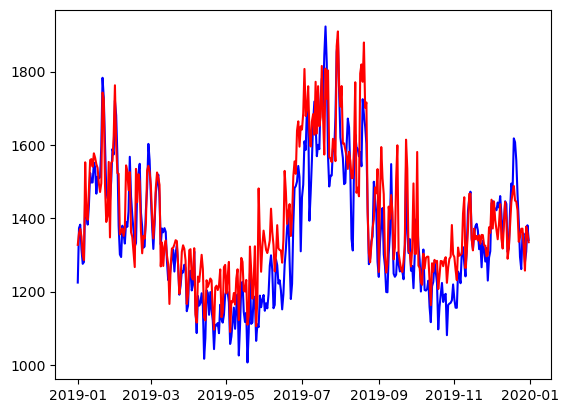

In [32]:
plt.plot(y_test, color='blue')
plt.plot(y_test_pred, color='red')

<AxesSubplot:xlabel='DATE'>

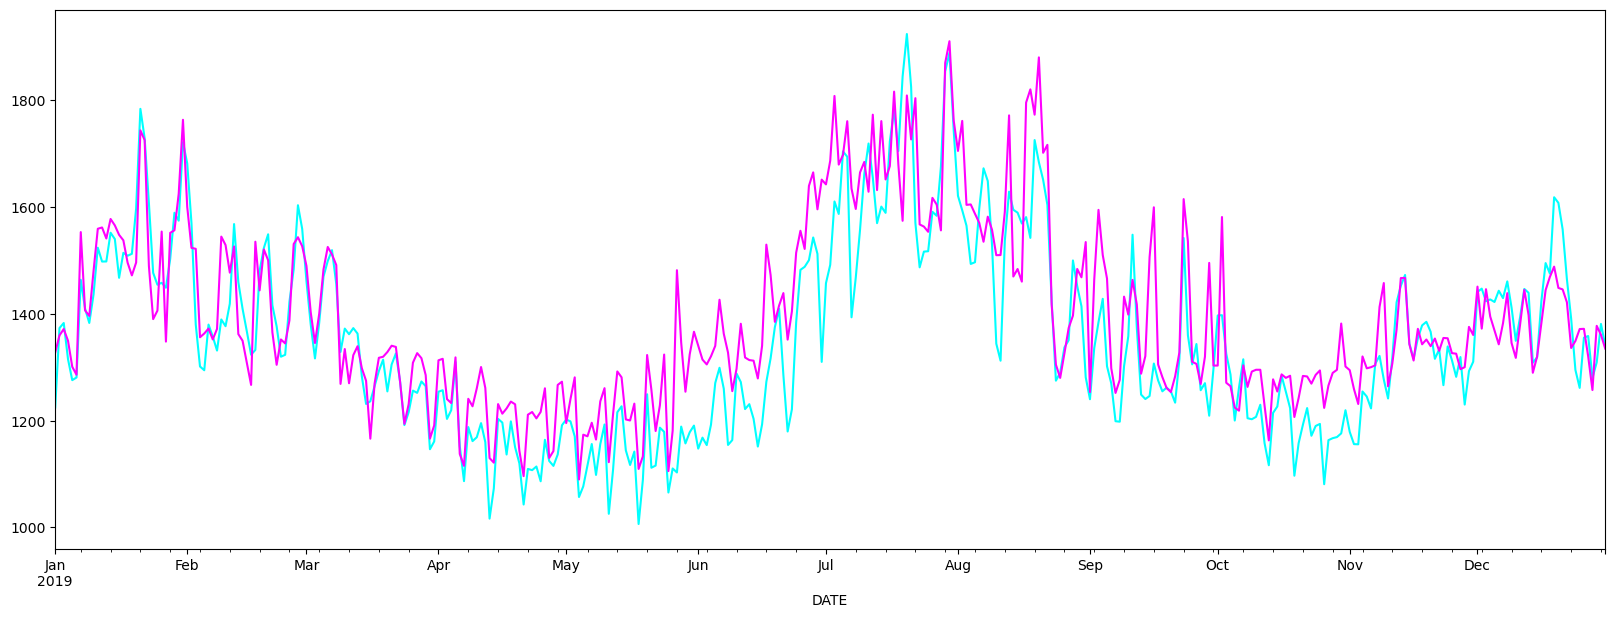

In [33]:
fig, ax = plt.subplots(figsize=(20,7))
y_test.plot(ax=ax, color='cyan')
y_test_pred.plot(ax=ax, color='magenta')